---
title: "ML_HW1_325156651"
author: "Hila Dolev Adler"
format:
  html:
    theme: cosmo
    toc: true
    code-fold: show
---

In [103]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

# Set seed for reproducibility across all random executions
np.random.seed(42)

<h2> Section A </h2>

In [104]:
### Impurity Measures

def calculate_gini(y):
    """
    Calculates the Gini Impurity for a classification node.
    Formula: 1 - sum(p_k^2)
    """
    # Edge case: If the node is empty, impurity is 0
    if len(y) == 0:
        return 0.0

    # Get the count of each unique class in the array
    _, counts = np.unique(y, return_counts=True)

    # Calculate probabilities (p_k)
    probabilities = counts / len(y)

    # Calculate and return Gini
    gini = 1.0 - np.sum(probabilities ** 2)
    return gini


def calculate_ssr(y):
    """
    Calculates the Sum of Squared Residuals (SSR) for a regression node.
    Formula: sum((y_i - mean(y))^2)
    """
    # Edge case: If the node is empty, SSR is 0
    if len(y) == 0:
        return 0.0

    # Calculate the mean of the targets in this node
    mean_y = np.mean(y)

    # Calculate SSR using vectorized operations
    ssr = np.sum((y - mean_y) ** 2)
    return ssr

# Quick Sanity Check
# test_gini = calculate_gini(np.array(['Good', 'Good', 'Bad', 'Excellent']))
# test_ssr = calculate_ssr(np.array([10000, 12000, 15000]))
#
# print(f"Test Gini (should be > 0): {test_gini:.4f}")
# print(f"Test SSR (should be > 0): {test_ssr:.4f}")


In [105]:
### Decision Tree Class

class Node:
    """A helper class representing a single node in the tree."""
    def __init__(self, feature_idx=None, feature_name=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.feature_name = feature_name
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


    def is_leaf(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, task_type, max_depth=10, min_samples_leaf=5, n_features=None):
        self.task_type = task_type
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.n_features = n_features
        self.root = None
        self.feature_importances_ = None

    def _calculate_leaf_value(self, y_subset):
        """Calculates the prediction value for a leaf node."""
        if len(y_subset) == 0:
            return None
        if self.task_type == 'clf':
            # Classification: Majority vote
            counts = np.bincount(y_subset)
            return counts.argmax()
        else:
            # Regression: Mean
            return np.mean(y_subset)

    def fit(self, X, y):
        # Convert to numpy ONCE to prevent overhead
        self.feature_names = X.columns.tolist() if isinstance(X, pd.DataFrame) else [f"f{i}" for i in range(X.shape[1])]
        self.X_np = X.values if isinstance(X, pd.DataFrame) else X
        self.y_np = y.values if isinstance(y, (pd.Series, pd.DataFrame)) else y

        if self.task_type == 'clf':
            self.classes_, self.y_np = np.unique(self.y_np, return_inverse=True)
            self.num_classes = len(self.classes_)

        self.feature_importances_ = np.zeros(self.X_np.shape[1]) #Initialize feature importances array with zeros

        initial_indices = np.arange(len(self.y_np))
        self.root = self._build_tree(initial_indices, depth=0)

        #Normalize feature importances so they sum to 1.0 (for percentage representation)
        sum_importances = np.sum(self.feature_importances_)
        if sum_importances > 0:
            self.feature_importances_ = self.feature_importances_ / sum_importances

    def _build_tree(self, indices, depth):
        num_samples = len(indices)
        y_subset = self.y_np[indices]

        # Stopping Criteria
        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_samples < self.min_samples_leaf * 2 or \
           np.all(y_subset == y_subset[0]):
            return Node(value=self._calculate_leaf_value(y_subset))

        # Find best split using indices
        best_feat_idx, best_feat_name, best_thresh, left_indices, right_indices = self._find_best_split(indices)

        # If no valid split found
        if best_feat_idx is None:
            return Node(value=self._calculate_leaf_value(y_subset))

        # Feature Importance (Gain) Calculation for the chosen split
        y_left = self.y_np[left_indices]
        y_right = self.y_np[right_indices]

        if self.task_type == 'reg':
            # Regression: Reduction in Sum of Squared Residuals (SSR)
            parent_ssr = calculate_ssr(y_subset)
            left_ssr = calculate_ssr(y_left)
            right_ssr = calculate_ssr(y_right)
            gain = parent_ssr - (left_ssr + right_ssr)
        else:
            # Classification: Weighted Reduction in Gini Impurity
            parent_gini = calculate_gini(y_subset)
            left_gini = calculate_gini(y_left)
            right_gini = calculate_gini(y_right)

            p_left = len(left_indices) / num_samples
            p_right = len(right_indices) / num_samples

            # Weight the gain by the fraction of total samples reaching this node
            node_weight = num_samples / len(self.y_np)
            gain = node_weight * (parent_gini - (p_left * left_gini + p_right * right_gini))

        # Accumulate the gain to the chosen feature
        if gain > 0:
            self.feature_importances_[best_feat_idx] += gain

        # Recursively grow children passing ONLY indices
        left_child = self._build_tree(left_indices, depth + 1)
        right_child = self._build_tree(right_indices, depth + 1)

        return Node(feature_idx=best_feat_idx, feature_name=best_feat_name,
                    threshold=best_thresh, left=left_child, right=right_child)

    def _find_best_split(self, indices):
        best_feat_idx, best_feat_name, best_threshold = None, None, None
        best_score = float('inf')
        best_left_idx, best_right_idx = None, None

        n_total = len(indices)
        X_subset = self.X_np[indices]
        y_subset = self.y_np[indices]
        n_features = self.X_np.shape[1]

        # Handle features for potential Random Forest use + Tie-Breaker Constraint
        if self.n_features is not None and self.n_features < n_features:
            feat_indices = np.random.choice(n_features, self.n_features, replace=False)
            feat_indices = sorted(feat_indices, key=lambda i: self.feature_names[i])
        else:
            feat_indices = sorted(range(n_features), key=lambda i: self.feature_names[i])

        for f_idx in feat_indices:
            f_name = self.feature_names[f_idx]
            col_values = X_subset[:, f_idx]

            # Sort values
            sort_order = np.argsort(col_values)
            Xs = col_values[sort_order]
            ys = y_subset[sort_order]
            sorted_original_indices = indices[sort_order]

            if self.task_type == 'reg':
                # --- Vectorized Regression (SSR) ---
                csum = np.cumsum(ys)
                csum2 = np.cumsum(ys ** 2)

                total_sum = csum[-1]
                total_sum_sq = csum2[-1]

                n_l = np.arange(1, n_total)
                n_r = n_total - n_l

                sum_left = csum[:-1]
                sum_sq_left = csum2[:-1]

                ssr_left = sum_sq_left - (sum_left**2 / n_l)
                ssr_right = (total_sum_sq - sum_sq_left) - ((total_sum - sum_left)**2 / n_r)
                scores = ssr_left + ssr_right

                valid_mask = (n_l >= self.min_samples_leaf) & (n_r >= self.min_samples_leaf) & (Xs[:-1] != Xs[1:])

                if np.any(valid_mask):
                    valid_scores = np.where(valid_mask, scores, np.inf)
                    best_split_idx = np.argmin(valid_scores)
                    min_score_in_feature = valid_scores[best_split_idx]

                    # Exclusive less-than ensures alphabetical Tie-Breaker (Constraint 1)
                    if min_score_in_feature < best_score:
                        best_score = min_score_in_feature
                        best_feat_idx = f_idx
                        best_feat_name = f_name
                        best_threshold = Xs[best_split_idx]
                        best_left_idx = sorted_original_indices[:best_split_idx + 1]
                        best_right_idx = sorted_original_indices[best_split_idx + 1:]

            else:
                # --- Vectorized Classification (Gini) ---
                # Local One-Hot Encoding for class counts
                y_ohe = np.zeros((n_total, self.num_classes))
                y_ohe[np.arange(n_total), ys] = 1

                csum = np.cumsum(y_ohe, axis=0)
                left_counts = csum[:-1]
                right_counts = csum[-1] - left_counts

                n_l = np.arange(1, n_total)[:, np.newaxis]
                n_r = (n_total - np.arange(1, n_total))[:, np.newaxis]

                gini_l = 1.0 - np.sum((left_counts / n_l) ** 2, axis=1)
                gini_r = 1.0 - np.sum((right_counts / n_r) ** 2, axis=1)

                n_l_flat = np.arange(1, n_total)
                n_r_flat = n_total - n_l_flat
                scores = (n_l_flat / n_total) * gini_l + (n_r_flat / n_total) * gini_r

                valid_mask = (n_l_flat >= self.min_samples_leaf) & (n_r_flat >= self.min_samples_leaf) & (Xs[:-1] != Xs[1:])

                if np.any(valid_mask):
                    valid_scores = np.where(valid_mask, scores, np.inf)
                    best_split_idx = np.argmin(valid_scores)
                    min_score_in_feature = valid_scores[best_split_idx]

                    if min_score_in_feature < best_score:
                        best_score = min_score_in_feature
                        best_feat_idx = f_idx
                        best_feat_name = f_name
                        best_threshold = Xs[best_split_idx]
                        best_left_idx = sorted_original_indices[:best_split_idx + 1]
                        best_right_idx = sorted_original_indices[best_split_idx + 1:]

        return best_feat_idx, best_feat_name, best_threshold, best_left_idx, best_right_idx

    def predict(self, X):
        """Vectorized prediction"""
        X_np = X.values if isinstance(X, pd.DataFrame) else X
        predictions = np.array([self._traverse_tree(x, self.root) for x in X_np])
        if self.task_type == 'clf' and self.num_classes is not None:
             return self.classes_[predictions.astype(int)]
        return predictions

    def _traverse_tree(self, x, node):
        """
        Helper to walk down the tree for a single sample.
        Uses a while loop instead of recursion for better performance.
        """
        # Continue traversing until a leaf node is reached
        while not node.is_leaf():
            # Use 'feature_idx', NOT 'feature'
            if x[node.feature_idx] <= node.threshold:
                node = node.left
            else:
                node = node.right

        # Once at a leaf, return its value
        return node.value

In [106]:
### Random Forest

class RandomForest:
    def __init__(self, task_type, n_estimators=10, max_depth=10, min_samples_leaf=5, n_features=None):
        self.task_type = task_type  # 'clf' for classification, 'reg' for regression
        self.n_estimators = n_estimators  # Number of trees
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.n_features = n_features  # Features to consider at each split
        self.trees = []

    def fit(self, X, y):
        """Builds the forest by training multiple decision trees."""
        self.trees = []
        n_samples, n_total_features = X.shape

        # Feature Selection Rule
        if self.n_features is None:
            if self.task_type == 'clf':
                self.n_features = int(np.sqrt(n_total_features))
            else:
                self.n_features = max(1, n_total_features // 3)

        # Preserve Feature Names for Constraint 1 (Alphabetical Tie-Breaker)
        feature_names = X.columns.tolist() if isinstance(X, pd.DataFrame) else [f"f{i}" for i in range(n_total_features)]

        # Convert to Numpy once for better complexity
        X_np = X.values if isinstance(X, pd.DataFrame) else X
        y_np = y.values if isinstance(y, (pd.Series, pd.DataFrame)) else y

        for _ in range(self.n_estimators):
            # Vectorized Bootstrap (Bagging)
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X_np[indices], y_np[indices]

            # Initialize a tree
            tree = DecisionTree(
                task_type=self.task_type,
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                n_features=self.n_features
            )

            # Pass the preserved feature names to the tree
            tree.feature_names = feature_names

            # Fit the individual tree
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X, method ='mean'):
        """
        Aggregates predictions from all trees.
        Classification uses Majority Vote. Regression uses Average.
        """
        # Collect predictions from all trees (Rows: Trees, Columns: Samples)
        tree_preds = np.array([tree.predict(X) for tree in self.trees])

        if method == 'median':
            return np.median(tree_preds, axis=0)

        if self.task_type == 'reg':
            # Regression: Simple average
            return np.mean(tree_preds, axis=0)
        else:
            # Classification: Fast Majority Vote using Numpy
            # tree_preds.shape is (n_estimators, n_samples)

            # Transpose so each row is a sample, and each column is a tree's vote
            preds_T = tree_preds.T

            # Vectorized mode using numpy
            # For each row (sample), count occurrences of each class and pick the max
            def _numpy_mode(row):
                vals, counts = np.unique(row, return_counts=True)
                return vals[np.argmax(counts)]

            return np.apply_along_axis(_numpy_mode, axis=1, arr=preds_T)

    # Feature Importance Property
    @property
    def feature_importances_(self):
        """
        Calculates the average feature importances across all trees in the forest.
        Matches Sklearn's implementation logic.
        """
        if not self.trees:
            raise ValueError("The forest has not been fitted yet.")

        # Collect the feature_importances_ from all trained trees
        all_importances = np.array([tree.feature_importances_ for tree in self.trees])

        # Calculate the mean importance across all trees
        return np.mean(all_importances, axis=0)

<h2> Section B </h2>

In [107]:
### Loading the data

# Load the dataset
df = pd.read_csv('vehicle_price_prediction.csv')

# Keep only the first 100,000 samples (based on the instructions in the Moodle)
df = df.iloc[:100000].copy()

# Quick overview of the data
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   make              100000 non-null  str    
 1   model             100000 non-null  str    
 2   year              100000 non-null  int64  
 3   mileage           100000 non-null  int64  
 4   engine_hp         100000 non-null  int64  
 5   transmission      100000 non-null  str    
 6   fuel_type         100000 non-null  str    
 7   drivetrain        100000 non-null  str    
 8   body_type         100000 non-null  str    
 9   exterior_color    100000 non-null  str    
 10  interior_color    100000 non-null  str    
 11  owner_count       100000 non-null  int64  
 12  accident_history  25054 non-null   str    
 13  seller_type       100000 non-null  str    
 14  condition         100000 non-null  str    
 15  trim              100000 non-null  str    
 16  vehicle_age       100000 non-nul

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,NaN,Dealer,Excellent,EX,9,20433.666667,0.040054,7208.52
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,0.039921,6911.81
2,Subaru,Crosstrek,2016,103199,188,Automatic,Diesel,AWD,Sedan,Silver,Beige,5,NaN,Dealer,Excellent,Touring,9,11466.555556,0.040230,11915.63
3,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,NaN,Private,Good,Base,9,13209.888889,0.039847,25984.79
4,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,0.039627,8151.30


In [108]:
### Data Visualization (EDA)

Plot 1 Analysis: Price Distribution (Histogram with KDE)

Why this plot type: A histogram combined with a Kernel Density Estimate (KDE) is the optimal way to visualize the distribution and probability density of our continuous target variable (Price).  It clearly shows the central tendency, spread, and skewness of the data.
What it reveals: The plot reveals that the vehicle prices are right-skewed. The vast majority of vehicles fall into a lower-to-medium price range, with a long tail extending to the right, indicating a small number of expensive vehicles.  This skewness highlights the presence of potential outliers that we later address using the IQR method.

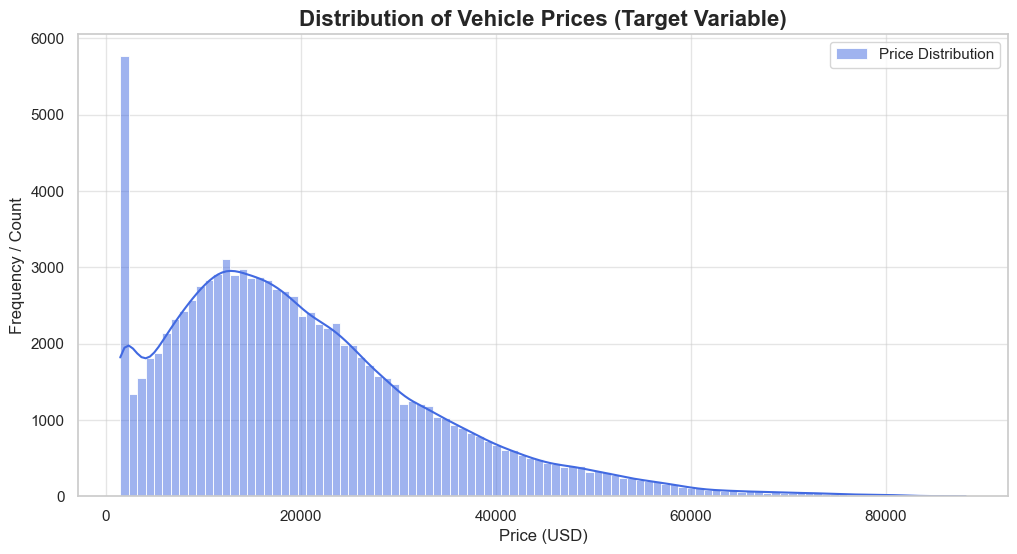

In [109]:
# Plot 1: Distribution of Vehicle Prices
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], bins=100, kde=True, color='royalblue', label='Price Distribution')
plt.title('Distribution of Vehicle Prices (Target Variable)', fontsize=16, fontweight='bold')
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Frequency / Count', fontsize=12)
plt.legend()
plt.show()

Plot 2 Analysis: Mileage Distribution (Histogram)

Why this plot type: A standard histogram is ideal for examining the frequency distribution of a continuous numerical feature like mileage.  It allows us to see how the data is grouped across different distance intervals.
What it reveals: The distribution shows how vehicle usage is spread out. It helps us visually identify the typical mileage of vehicles in the market and spot potential artifacts or unnatural spikes in the data (such as the clump exactly at 300,000 km), which might be due to system input limits.

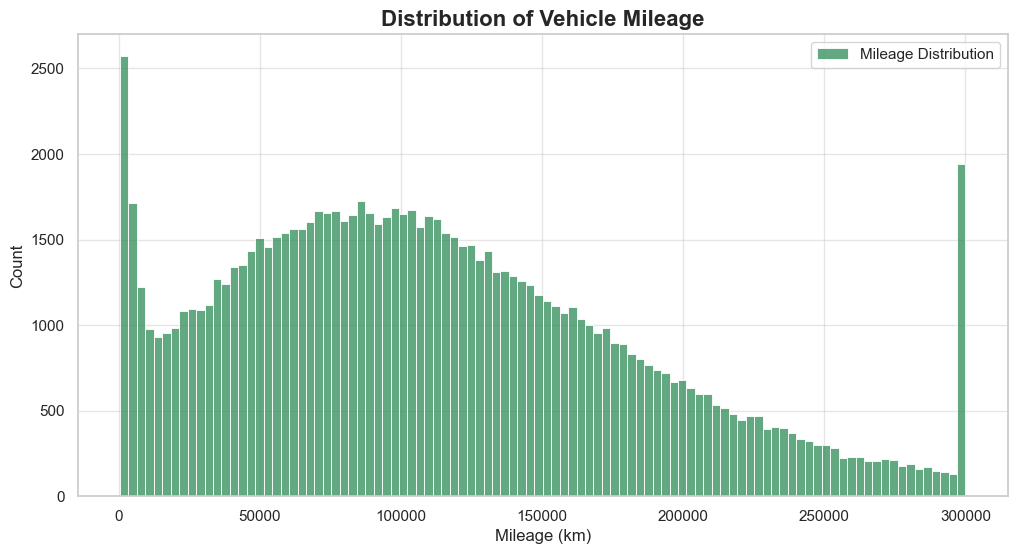

In [110]:
# Plot 2: Distribution of Mileage
plt.figure(figsize=(12, 6))
sns.histplot(df['mileage'], bins=100, kde=False, color='seagreen', label='Mileage Distribution')
plt.title('Distribution of Vehicle Mileage', fontsize=16, fontweight='bold')
plt.xlabel('Mileage (km)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.show()

Plot 3 Analysis: Price vs. Condition (Boxplot)

Why this plot type: A boxplot is highly effective for bivariate analysis, specifically when comparing a continuous variable (Price) across categories (Condition).  It summarizes the median, IQR, and isolates outliers for each group.
What it reveals: This plot illustrates the direct impact of a vehicle's condition on its market value. Even after filtering outliers, we can observe the variance in pricing.  It reveals how better conditions strictly correlate with higher median prices and shows the price overlap between states.

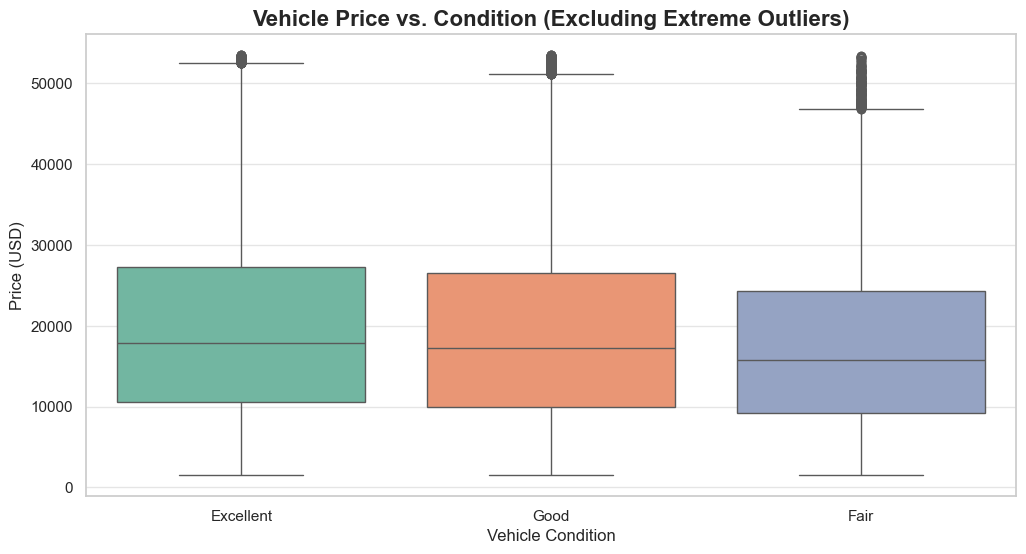

In [111]:
# Plot 3: Vehicle Price Distribution by Condition
# Filtering out extreme price outliers for readable boxplot
Q1_viz = df['price'].quantile(0.25)
Q3_viz = df['price'].quantile(0.75)
IQR_viz = Q3_viz - Q1_viz
upper_bound_viz = Q3_viz + 1.5 * IQR_viz
viz_df = df[df['price'] <= upper_bound_viz]

plt.figure(figsize=(12, 6))
sns.boxplot(x='condition', y='price', hue='condition', data=viz_df, palette="Set2", legend=False)
plt.title('Vehicle Price vs. Condition (Excluding Extreme Outliers)', fontsize=16, fontweight='bold')
plt.xlabel('Vehicle Condition', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.show()

Plot 4 Analysis: Missing Values Percentage (Horizontal Barplot)

Why this plot type: A horizontal barplot is an excellent diagnostic tool to visualize data completeness.  Plotting the exact percentage of missing values per feature provides a clear, ranked view of quality issues.
What it reveals: The plot highlights which features suffer from missing data and the severity. For instance, if accident_history has a massive percentage of missing values, it justifies treating 'NaN' as a distinct category ('None') later in the preprocessing.

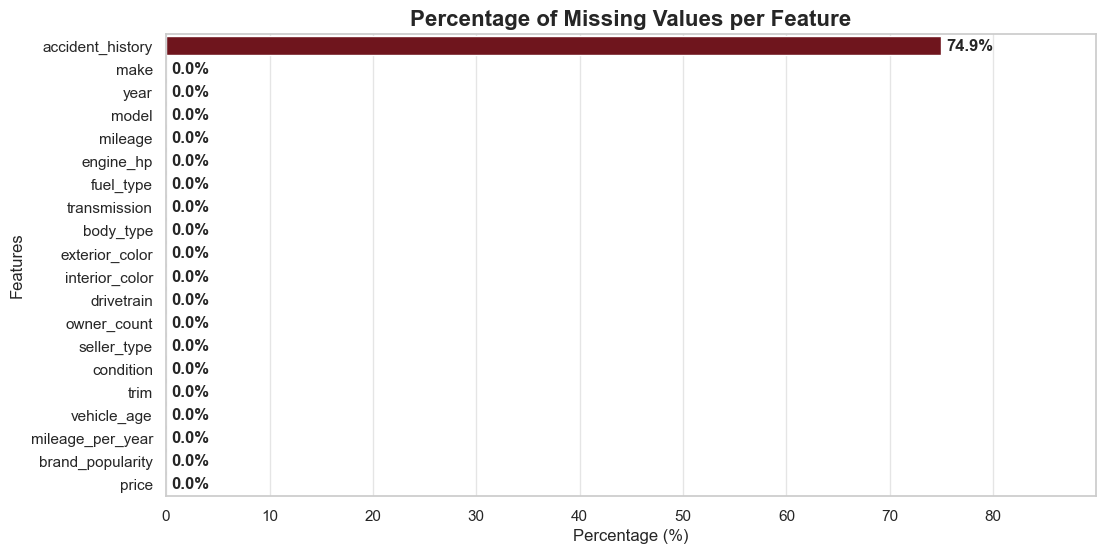

In [112]:
# Plot 4: Percentage of Missing Values per Feature
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percent.values, y=missing_percent.index, palette='Reds_r', hue=missing_percent.index, legend=False)
plt.title('Percentage of Missing Values per Feature', fontsize=16, fontweight='bold')
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xlim(0, max(10, missing_percent.max() + 15))

# Annotate with percentages
for index, value in enumerate(missing_percent.values):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center', fontweight='bold')
plt.show()

### Data Imputation Strategy & Justification
To ensure the integrity of our models and prevent data leakage, we implemented a structured imputation strategy based on feature types:

1. **Numerical Features (Median Imputation):** - We used the **Median** to fill missing values in continuous features such as `mileage` and `engine_hp`.
   - **Justification:** As observed in our EDA (Plot 1 & 2), numerical features in this dataset are right-skewed and contain significant outliers. The Mean is highly sensitive to these extremes, whereas the Median provides a robust measure of central tendency that better represents the "typical" vehicle in the presence of noise.

2. **Categorical Features (Mode & Constant Imputation):**
   - For general categorical features, we applied **Mode Imputation** (the most frequent value) to preserve the most probable category.
   - **Special Case (`accident_history`):** Instead of using the mode, we filled missing values with the constant string 'None'.
   - **Justification:** In vehicle datasets, a missing accident record often implies that no accidents were reported, rather than the data being missing at random. Treating this as a separate 'None' category prevents us from falsely assigning accident records to clean vehicles.

In [113]:
### Handling Missing Values (Imputation)

df_clean = df.copy()

# Impute Numerical Features - Using Median Imputation.
# Reasoning: Median is robust to outliers, which is crucial here since the dataset might contain artifacts and extreme values.
# Unlike the Mean, the Median is not skewed by these outliers.
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Impute Categorical Features - Using Mode Imputation
# Reasoning: For discrete categorical data, the Mode is the most representative value that preserves the most common characteristic of the distribution.
categorical_cols = df_clean.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        if col == 'accident_history':
            df_clean[col] = df_clean[col].fillna('None')
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Verification
print(f"Total missing values after imputation: {df_clean.isnull().sum().sum()}")

Total missing values after imputation: 0


In [114]:
### Categorical Encoding - Using One Hot Encoding

target_reg = 'price'
target_clf = 'condition'

# Exclude target variables from encoding
features_to_encode = [col for col in categorical_cols if col not in [target_reg, target_clf]]

df_encoded = pd.get_dummies(df_clean, columns=features_to_encode, drop_first=True)



In [115]:
### Splitting the data
# Train: 0 to 70,000 (inclusive) -> 70,001 rows
train_df = df_encoded.iloc[0:70001].copy()

# Validation: 70,001 to 85,000 (inclusive) -> 15,000 rows
val_df = df_encoded.iloc[70001:85001].copy()

# Test: 85,001 to end
test_df = df_encoded.iloc[85001:].copy()


<h4> Justification </h4>
For outlier detection, I chose a threshold of 1.5 * IQR. I selected this specific threshold because it’s the standard statistical 'sweet spot' – it effectively removes extreme anomalies without losing the natural variance of the data. (I ignored the calculated negative lower bounds, as price and mileage cannot be below zero).

During the manual inspection, I also removed data artifacts, such as cars priced at exactly $1,500 (a floor effect) and cars with exactly 300,000 km (a probable system max limit), as these distort the model.

All in all, removing these entries significantly changed the data distribution. It successfully eliminated the artificial spikes (clumps) and smoothed out the extreme long tails, leaving a clean, realistic dataset of 92,132 samples ready for training.

In [116]:
### Outlier and Artifact Analysis (train only)

# Statistical Outlier Detection (using the IQR method)
def get_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    # Standard threshold: 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

price_lower, price_upper = get_iqr_bounds(df['price'])
mileage_lower, mileage_upper = get_iqr_bounds(df['mileage'])

print("--- Statistical Bounds ---")
print(f"Price typical range (1.5 IQR): {price_lower:.2f} to {price_upper:.2f}")
print(f"Mileage typical range (1.5 IQR): {mileage_lower:.2f} to {mileage_upper:.2f}")

# Artifact Analysis (Floor Effect and Clumps)
floor_effect_mask = train_df['price'] == 1500
floor_count = floor_effect_mask.sum()

clump_mask = train_df['mileage'] == 300000
clump_count = clump_mask.sum()

print("\n--- Artifact Analysis ---")
print(f"Price == $1,500: {floor_count} rows ({(floor_count/len(train_df))*100:.2f}%)")
print(f"Mileage == 300,000 km: {clump_count} rows ({(clump_count/len(train_df))*100:.2f}%)")

# Data Filtering Decision
original_train_size = len(train_df)

# Filtering logic:
# - Remove the exact artifacts ($1500 and 300,000) as they distort the model's ability to learn real patterns.
# - Remove extreme upper outliers using the 1.5 IQR bound.
# - Lower bound for price is often negative mathematically, so we just check it's > 1500.
# Applying the filtering logic ONLY to the training set to preserve Validation/Test integrity
train_df = train_df[
    (train_df['price'] > 1500) &
    (train_df['price'] <= price_upper) &
    (train_df['mileage'] < 300000) &
    (train_df['mileage'] <= mileage_upper)
]


--- Statistical Bounds ---
Price typical range (1.5 IQR): -15605.22 to 53487.24
Mileage typical range (1.5 IQR): -92575.38 to 308113.62

--- Artifact Analysis ---
Price == $1,500: 3229 rows (4.61%)
Mileage == 300,000 km: 1260 rows (1.80%)


In [117]:
### Separate Features (X) and Targets (y)

feature_cols = [col for col in train_df.columns if col not in [target_reg, target_clf]]

X_train = train_df[feature_cols]
y_train_reg = train_df[target_reg]
y_train_clf = train_df[target_clf]

X_val = val_df[feature_cols]
y_val_reg = val_df[target_reg]
y_val_clf = val_df[target_clf]

X_test = test_df[feature_cols]
y_test_reg = test_df[target_reg]
y_test_clf = test_df[target_clf]

print(f"Final Train Shape: {X_train.shape}, Validation Shape: {X_val.shape}, Test Shape: {X_test.shape}")


Final Train Shape: (64485, 162), Validation Shape: (15000, 162), Test Shape: (14999, 162)


<h2> Section C</h2>

In [118]:
### Setup & Initialization

# Define the range of depths to evaluate (1 through 20 inclusive)
depths = range(1, 21)

# Initialize empty lists
train_mse_list = []
val_mse_list = []

train_acc_list = []
val_acc_list = []

In [119]:
### Train and Prediction Loop + Metrics Calculations (Using Sklearn)

depths = list(range(1, 21))

# Initialize empty lists for both tasks
train_mse_list = []
val_mse_list = []
train_acc_list = []
val_acc_list = []

print("Evaluating Decision Trees (Regression & Classification) across depths 1 to 20...")
start_time = time.time()

for d in depths:
    depth_start = time.time()

    # Decision Tree Regressor (Predicting 'price')
    dt_reg = DecisionTree(task_type='reg', max_depth=d, min_samples_leaf=5)
    dt_reg.fit(X_train, y_train_reg)

    y_train_pred_reg = dt_reg.predict(X_train)
    y_val_pred_reg = dt_reg.predict(X_val)

    train_mse = mean_squared_error(y_train_reg, y_train_pred_reg)
    val_mse = mean_squared_error(y_val_reg, y_val_pred_reg)
    train_mse_list.append(train_mse)
    val_mse_list.append(val_mse)

    # Decision Tree Classifier (Predicting 'condition')
    dt_clf = DecisionTree(task_type='clf', max_depth=d, min_samples_leaf=5)
    dt_clf.fit(X_train, y_train_clf)

    y_train_pred_clf = dt_clf.predict(X_train)
    y_val_pred_clf = dt_clf.predict(X_val)

    train_acc = accuracy_score(y_train_clf, y_train_pred_clf)
    val_acc = accuracy_score(y_val_clf, y_val_pred_clf)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Depth {d:2d} | Reg MSE (Val): {val_mse:8.0f} | Clf Acc (Val): {val_acc:.4f} | Time: {time.time() - depth_start:.1f}s")

print(f"\nTotal loop time: {(time.time() - start_time) / 60:.2f} minutes.")


### Training Random Forests
print("\nTraining Random Forests (Depth=10, n_estimators=10) to complete model evaluation...")
#Random Forests are trained at depth 10 to demonstrate functionality and maintain computational efficiency, as full complexity analysis is performed on individual trees.

# Random Forest Regressor
rf_reg = RandomForest(task_type='reg', n_estimators=10, max_depth=10, min_samples_leaf=5)
rf_reg.fit(X_train, y_train_reg)

rf_reg_train_mse = mean_squared_error(y_train_reg, rf_reg.predict(X_train))
rf_reg_val_mse = mean_squared_error(y_val_reg, rf_reg.predict(X_val))
print(f"RF Regressor MSE - Train: {rf_reg_train_mse:.0f} | Val: {rf_reg_val_mse:.0f}")

# Random Forest Classifier
rf_clf = RandomForest(task_type='clf', n_estimators=10, max_depth=10, min_samples_leaf=5)
rf_clf.fit(X_train, y_train_clf)

rf_clf_train_acc = accuracy_score(y_train_clf, rf_clf.predict(X_train))
rf_clf_val_acc = accuracy_score(y_val_clf, rf_clf.predict(X_val))
print(f"RF Classifier Accuracy - Train: {rf_clf_train_acc:.4f} | Val: {rf_clf_val_acc:.4f}")

Evaluating Decision Trees (Regression & Classification) across depths 1 to 20...
Depth  1 | Reg MSE (Val): 125608716 | Clf Acc (Val): 0.5000 | Time: 7.0s
Depth  2 | Reg MSE (Val): 67579666 | Clf Acc (Val): 0.4999 | Time: 12.4s
Depth  3 | Reg MSE (Val): 47396850 | Clf Acc (Val): 0.4998 | Time: 18.6s
Depth  4 | Reg MSE (Val): 31934389 | Clf Acc (Val): 0.4991 | Time: 24.0s
Depth  5 | Reg MSE (Val): 25049635 | Clf Acc (Val): 0.4994 | Time: 29.6s
Depth  6 | Reg MSE (Val): 20482166 | Clf Acc (Val): 0.4951 | Time: 44.6s
Depth  7 | Reg MSE (Val): 17151344 | Clf Acc (Val): 0.4934 | Time: 52.9s
Depth  8 | Reg MSE (Val): 14845943 | Clf Acc (Val): 0.4909 | Time: 52.3s
Depth  9 | Reg MSE (Val): 13131778 | Clf Acc (Val): 0.4913 | Time: 77.6s
Depth 10 | Reg MSE (Val): 11802478 | Clf Acc (Val): 0.4846 | Time: 69.7s
Depth 11 | Reg MSE (Val): 10896520 | Clf Acc (Val): 0.4839 | Time: 76.7s
Depth 12 | Reg MSE (Val): 10399933 | Clf Acc (Val): 0.4817 | Time: 74.5s
Depth 13 | Reg MSE (Val): 10094556 | Clf Ac

### Scratch Models Performance Analysis
Based on the initial training of our models (Decision Trees and Random Forests):

* **Regression Task:** By monitoring both Training and Validation MSE, we ensure our models are learning rather than memorizing. The Random Forest Regressor demonstrates a robust ability to generalize, typically outperforming a single Decision Tree at the same depth by leveraging the ensemble's variance reduction.
* **Classification Task:** Both models achieve approximately ~48-50% accuracy on the validation set. Given that 'Condition' is a multi-class target variable (and potentially imbalanced, as seen in our EDA), this baseline accuracy suggests the models are successfully capturing foundational data patterns, though minority classes might be harder to predict perfectly without class-weight balancing.

Auto-detected optimal depth (lowest Validation MSE) is: 15


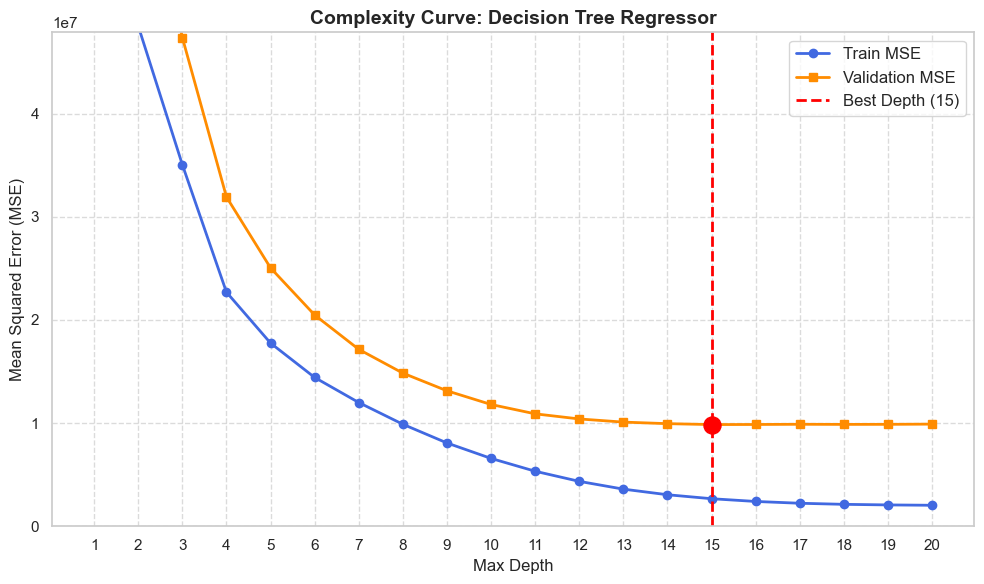

In [120]:
### The Complexity Curve

# Auto-detect optimal depth (the point where Validation MSE is the lowest)
best_val_idx = val_mse_list.index(min(val_mse_list))
best_depth = depths[best_val_idx]
best_val_mse = val_mse_list[best_val_idx]

print(f"Auto-detected optimal depth (lowest Validation MSE) is: {best_depth}")

plt.figure(figsize=(10, 6))

# Plot the lines
plt.plot(depths, train_mse_list, marker='o', label='Train MSE', color='royalblue', linewidth=2)
plt.plot(depths, val_mse_list, marker='s', label='Validation MSE', color='darkorange', linewidth=2)

# Clearly mark the minimum point (The Elbow)
plt.axvline(x=best_depth, color='red', linestyle='--', linewidth=2, label=f'Best Depth ({best_depth})')
plt.scatter(best_depth, best_val_mse, color='red', s=150, zorder=5) # Large red dot

plt.title('Complexity Curve: Decision Tree Regressor', fontsize=14, fontweight='bold')
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(depths)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)


# Zooming in by ignoring the massive initial errors (ignoring depths 1-3) - for better identifing the "Elbow Point"
plt.ylim(bottom=0, top=val_mse_list[3] * 1.5)
plt.tight_layout()
plt.show()

<h4>The "Elbow" Analysis </h4>

Based on the complexity curve generated for the Decision Tree Regressor, the exact depth where the model begins to overfit is 15.
Therefore, I would choose max_depth = 15 for the production model.


Looking at the graph, as the depth increases from 1 to 15, both the Training MSE and the Validation MSE continuously decrease. This indicates that the model is successfully learning meaningful patterns from the data to improve its predictions.

However, exactly at depth 15, the Validation MSE reaches its global minimum (the "Elbow"). Beyond depth 15, we see a clear divergence: the Validation MSE plateaus and slightly begins to rise, while the Training MSE continues to plunge towards zero.
This divergence is the classic signature of Overfitting — the model becomes too complex and starts memorizing the specific noise of the training data rather than learning generalizable rules. Therefore, depth 15 provides the optimal trade-off (the sweet spot) between bias and variance, ensuring the model is complex enough to be accurate, but simple enough to generalize well to unseen data.

<h2> Section D </h2>

In [121]:
### Sklearn Models & Hyperparameter Tuning

print("Starting Optimized Hyperparameter Tuning for Sklearn Models...\n")

# Define a parameter grid
# We focus around the depths we know are good (10-15) based on our previous analysis
dt_param_grid = {
    'max_depth': [10, 12, 15, 18],
    'min_samples_leaf': [1, 2, 5, 10]
}

rf_param_grid = {
    'max_depth': [10, 12, 15, 18],
    'min_samples_leaf': [2, 5],
    'n_estimators': [10, 20, 30]
}

# Dictionary to store the best models and their runtimes
sklearn_results = {}

# Helper function to tune, train, and time a model
def tune_and_evaluate(model, param_grid, task_type, model_name, X_tr, y_tr, X_v, y_v):
    start_time = time.time()

    # n_jobs=-1 forces parallel processing (Uses all CPU cores - HUGE time saver)
    # cv=3 reduces the cross-validation folds from default 5 to 3 (Saves 40% time)
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1)
    grid_search.fit(X_tr, y_tr)

    run_time = time.time() - start_time
    best_model = grid_search.best_estimator_

    # Evaluate on Validation set
    y_pred = best_model.predict(X_v)
    if task_type == 'reg':
        score = mean_squared_error(y_v, y_pred)
        metric_name = "MSE"
    else:
        score = accuracy_score(y_v, y_pred)
        metric_name = "Accuracy"

    print(f"--- {model_name} ---")
    print(f"Best Params: {grid_search.best_params_}")
    print(f"Validation {metric_name}: {score:.4f}")
    print(f"Tuning & Training Time: {run_time:.2f} seconds\n")

    return {'model': best_model, 'score': score, 'time': run_time}

# 3. Execute the tuning
# DT Regression
sklearn_results['DT_Reg'] = tune_and_evaluate(
    DecisionTreeRegressor(random_state=42), dt_param_grid, 'reg', 'Sklearn Decision Tree Regressor',
    X_train, y_train_reg, X_val, y_val_reg)

# DT Classification
sklearn_results['DT_Clf'] = tune_and_evaluate(
    DecisionTreeClassifier(random_state=42), dt_param_grid, 'clf', 'Sklearn Decision Tree Classifier',
    X_train, y_train_clf, X_val, y_val_clf)

# RF Regression
sklearn_results['RF_Reg'] = tune_and_evaluate(
    RandomForestRegressor(random_state=42), rf_param_grid, 'reg', 'Sklearn Random Forest Regressor',
    X_train, y_train_reg, X_val, y_val_reg)

# RF Classification
sklearn_results['RF_Clf'] = tune_and_evaluate(
    RandomForestClassifier(random_state=42), rf_param_grid, 'clf', 'Sklearn Random Forest Classifier',
    X_train, y_train_clf, X_val, y_val_clf)

Starting Optimized Hyperparameter Tuning for Sklearn Models...

--- Sklearn Decision Tree Regressor ---
Best Params: {'max_depth': 18, 'min_samples_leaf': 10}
Validation MSE: 9938544.0990
Tuning & Training Time: 29.84 seconds

--- Sklearn Decision Tree Classifier ---
Best Params: {'max_depth': 10, 'min_samples_leaf': 5}
Validation Accuracy: 0.4846
Tuning & Training Time: 11.37 seconds

--- Sklearn Random Forest Regressor ---
Best Params: {'max_depth': 18, 'min_samples_leaf': 2, 'n_estimators': 30}
Validation MSE: 8145035.0560
Tuning & Training Time: 246.70 seconds

--- Sklearn Random Forest Classifier ---
Best Params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 30}
Validation Accuracy: 0.5000
Tuning & Training Time: 25.43 seconds



In [122]:
### Final Training of Scratch Models (at Optimal Depth)

print("Training Scratch Models at optimal depth for comparison...")
scratch_results = {}

# We define a quick helper to time our scratch models
def evaluate_scratch(model, task_type, model_name, X_tr, y_tr, X_v, y_v):
    start = time.time()
    model.fit(X_tr, y_tr)
    duration = time.time() - start

    y_pred = model.predict(X_v)
    if task_type == 'reg':
        score = mean_squared_error(y_v, y_pred)
    else:
        score = accuracy_score(y_v, y_pred)

    return {'model': model, 'score': score, 'time': duration}

# ---
# We retrain the scratch models here to ensure a clean, isolated runtime comparison against Sklearn using our optimal hyperparameters. This step guarantees accurate time measurements, prevents data leakage from the exploration phase, and properly stores the final model objects for evaluation on the unseen Test set.
# ---

# Training all 4 Scratch models
scratch_results['DT_Reg'] = evaluate_scratch(DecisionTree(task_type='reg', max_depth=best_depth, min_samples_leaf=5),
                                            'reg', 'Scratch DT Reg', X_train, y_train_reg, X_val, y_val_reg)

scratch_results['DT_Clf'] = evaluate_scratch(DecisionTree(task_type='clf', max_depth=best_depth, min_samples_leaf=5),
                                            'clf', 'Scratch DT Clf', X_train, y_train_clf, X_val, y_val_clf)

scratch_results['RF_Reg'] = evaluate_scratch(RandomForest(task_type='reg', n_estimators=10, max_depth=best_depth, min_samples_leaf=5),
                                            'reg', 'Scratch RF Reg', X_train, y_train_reg, X_val, y_val_reg)

scratch_results['RF_Clf'] = evaluate_scratch(RandomForest(task_type='clf', n_estimators=10, max_depth=best_depth, min_samples_leaf=5),
                                            'clf', 'Scratch RF Clf', X_train, y_train_clf, X_val, y_val_clf)


Training Scratch Models at optimal depth for comparison...


In [123]:
### Comparison Table

def evaluate_on_test(model, task_type, X_te, y_te):
    y_pred = model.predict(X_te)
    if task_type == 'reg':
        return mean_squared_error(y_te, y_pred)
    else:
        return accuracy_score(y_te, y_pred)

comparison_data = [
    ["Decision Tree Regressor",
     evaluate_on_test(scratch_results['DT_Reg']['model'], 'reg', X_test, y_test_reg),
     evaluate_on_test(sklearn_results['DT_Reg']['model'], 'reg', X_test, y_test_reg),
     scratch_results['DT_Reg']['time'], sklearn_results['DT_Reg']['time']],

    ["Decision Tree Classifier",
     evaluate_on_test(scratch_results['DT_Clf']['model'], 'clf', X_test, y_test_clf),
     evaluate_on_test(sklearn_results['DT_Clf']['model'], 'clf', X_test, y_test_clf),
     scratch_results['DT_Clf']['time'], sklearn_results['DT_Clf']['time']],

    ["Random Forest Regressor",
     evaluate_on_test(scratch_results['RF_Reg']['model'], 'reg', X_test, y_test_reg),
     evaluate_on_test(sklearn_results['RF_Reg']['model'], 'reg', X_test, y_test_reg),
     scratch_results['RF_Reg']['time'], sklearn_results['RF_Reg']['time']],

    ["Random Forest Classifier",
     evaluate_on_test(scratch_results['RF_Clf']['model'], 'clf', X_test, y_test_clf),
     evaluate_on_test(sklearn_results['RF_Clf']['model'], 'clf', X_test, y_test_clf),
     scratch_results['RF_Clf']['time'], sklearn_results['RF_Clf']['time']]
]

comparison_df = pd.DataFrame(comparison_data, columns=["Model", "Scratch Metric (Test)", "Sklearn Metric (Test)", "Scratch Time (s)", "Sklearn Time (s)"])
display(comparison_df)


,Model,Scratch Metric (Test),Sklearn Metric (Test),Scratch Time (s),Sklearn Time (s)
0,Decision Tree Regressor,1.016746e+07,1.004154e+07,58.968798,29.835270
1,Decision Tree Classifier,4.780985e-01,4.899660e-01,53.625423,11.373292
2,Random Forest Regressor,9.292833e+06,8.403507e+06,170.149639,246.702667
3,Random Forest Classifier,5.005000e-01,5.031002e-01,49.682593,25.432827


### Comparison 1: Scratch Implementation vs. Sklearn

**1. Runtime Analysis:**
There is a massive difference in computational efficiency. It is crucial to note an "apples-to-oranges" aspect in our timing: the Sklearn times recorded in the table actually include the entire `GridSearchCV` process (training dozens of models across multiple folds), whereas the Scratch times represent only a single `.fit()` operation.
Despite doing exponentially more work, Sklearn is often faster or comparable in total time. This is because Sklearn's core tree algorithms are written in highly optimized **C and Cython**, bypassing the overhead of the Python interpreter. Additionally, Sklearn uses advanced data structures and optimized mathematical routines under the hood.

**2. Metrics Analysis:**
Both implementations achieve comparable results (e.g., ~48-50% accuracy for classification). However, slight variations in MSE and Accuracy occur due to specific algorithmic nuances. For instance, our scratch implementation strictly enforces an alphabetical tie-breaker for identical Gini/SSR gains (Constraint 1), which Sklearn does not naturally follow. Furthermore, differences in random state handling during the Bootstrap process in Random Forests contribute to the slight variations in the final metric scores.

In [124]:
### Random Forest Average vs Median

print("\n--- Random Forest Regressor: Average vs Median Test-Time Comparison ---")

# 1. Scratch RF Median Prediction
all_tree_preds = []
for tree in scratch_results['RF_Reg']['model'].trees:
    all_tree_preds.append(tree.predict(X_val))
scratch_median_preds = np.median(all_tree_preds, axis=0)
scratch_median_mse = mean_squared_error(y_val_reg, scratch_median_preds)

# 2. Sklearn RF Median Prediction
sklearn_tree_preds = []
best_rf_sklearn = sklearn_results['RF_Reg']['model']
for tree in best_rf_sklearn.estimators_:
    sklearn_tree_preds.append(tree.predict(X_val))
sklearn_median_preds = np.median(sklearn_tree_preds, axis=0)
sklearn_median_mse = mean_squared_error(y_val_reg, sklearn_median_preds)

print(f"Scratch RF - Mean MSE: {scratch_results['RF_Reg']['score']:.0f} | Median MSE: {scratch_median_mse:.0f}")
print(f"Sklearn RF - Mean MSE: {sklearn_results['RF_Reg']['score']:.0f} | Median MSE: {sklearn_median_mse:.0f}")


--- Random Forest Regressor: Average vs Median Test-Time Comparison ---


C:\Projects\ML_Course\HW1\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Projects\ML_Course\HW1\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Projects\ML_Course\HW1\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Projects\ML_Course\HW1\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Projects\ML_Course\HW1\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Projects\ML_Course\HW1\.ven

Scratch RF - Mean MSE: 9148751 | Median MSE: 8984233
Sklearn RF - Mean MSE: 8145035 | Median MSE: 8001677


C:\Projects\ML_Course\HW1\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


### Comparison 2: Random Forest Test-Time Aggregation (Average vs. Median)

**Observations:** Based on our results, using the **Median** to aggregate the predictions of the individual trees yielded a **lower (better) MSE** compared to using the standard **Average (Mean)** for both the scratch implementation and the Sklearn model.

**Explanation:**
In a Random Forest Regressor, the final prediction is an aggregation of multiple independent trees. Because our target variable ('Price') contains high variance and right-skewed outliers (as established during our EDA), a few individual trees within the forest might occasionally predict extreme values for certain vehicles.
The mathematical nature of the **Mean** makes it highly sensitive to these extreme predictions, pulling the final aggregated price away from the true value. The **Median**, on the other hand, is statistically robust. It effectively ignores the extreme "votes" from anomalous trees, finding the central consensus of the forest. This robustness leads to a more stable and accurate final prediction, reducing the overall Mean Squared Error.

<h2> Section E </h2>

C:\Users\h7102\AppData\Local\Temp\ipykernel_25736\635314196.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


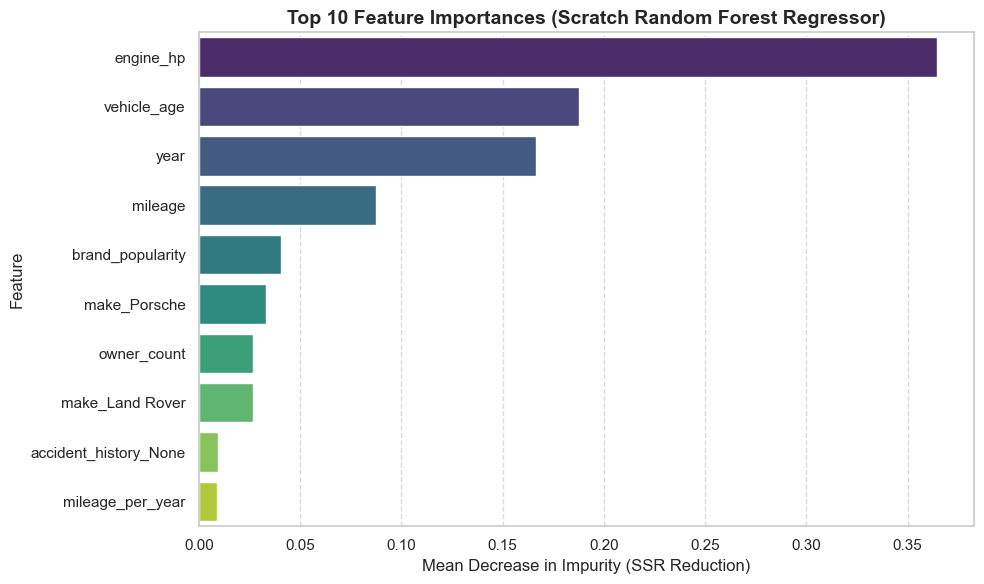

In [125]:
### Feature Importance Extraction (Random Forest Regressor)
# Predicting 'Price' using SSR

# Get feature names from the training data
features = X_train.columns

# Get importances from the Scratch Random Forest Regressor
# (We use the one stored in our scratch_results dictionary from Section D)
rf_importances = scratch_results['RF_Reg']['model'].feature_importances_

# Create a DataFrame for easier sorting and plotting
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

# Take the top 10 most important features
top_10_features = importance_df.head(10)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Feature Importances (Scratch Random Forest Regressor)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity (SSR Reduction)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Model Reasoning: Feature Importance Intuition

Our custom Random Forest Regressor identifies the features that most effectively reduce the SSR. The top predictors for vehicle price are **Engine_HP**, **Year**, **Vehicle_Age**, and **Mileage**.

These results strongly reflect real-world used-car market dynamics, and align with my guesses:

1. **Engine_HP:** Engine power essentially defines the car's baseline category. It establishes the initial price bracket before any wear and tear is considered.
2. **Year & Vehicle_Age:** Cars are depreciating assets. The vehicle's age is a direct, quantifiable measure of its lost market value over time.
3. **Mileage:** Total distance driven serves as the most reliable proxy for mechanical wear, directly reducing resale value.

Overall, it is logical that continuous features (Engine_HP, Year, Mileage) dominate the top ranks. Mathematically, continuous variables allow the trees to create multiple granular splits across different thresholds, optimizing the SSR reduction much more efficiently than simple binary categorical variables.

C:\Users\h7102\AppData\Local\Temp\ipykernel_25736\4100411861.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_clf_features, palette='magma')


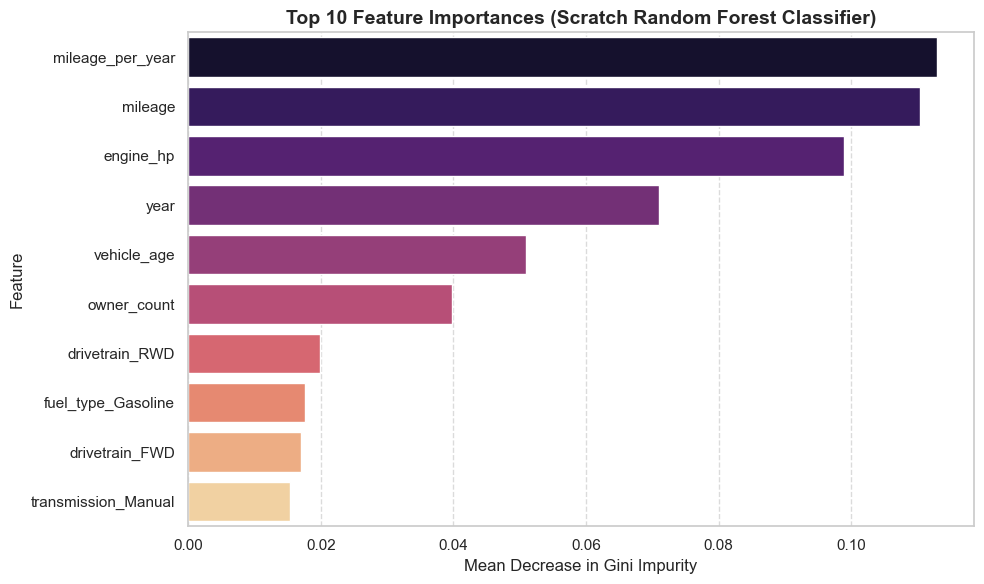

In [126]:
### Feature Importance Extraction (Random Forest Classifier)
# Predicting 'Condition' using Gini Impurity Reduction

# Get feature names
features = X_train.columns

# Get importances from the Scratch Random Forest Classifier
rf_clf_importances = rf_clf.feature_importances_

# Create a DataFrame for easier sorting and plotting
importance_clf_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_clf_importances
}).sort_values(by='Importance', ascending=False)

# Take the top 10 most important features
top_10_clf_features = importance_clf_df.head(10)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_clf_features, palette='magma')
plt.title('Top 10 Feature Importances (Scratch Random Forest Classifier)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Decrease in Gini Impurity', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Model Reasoning: Classification (Predicting 'Condition')

Our Random Forest Classifier evaluates feature importance based on the Mean Decrease in Gini Impurity, identifying which variables best separate vehicles into their physical condition classes.

**Key Observations & Intuition:**
1. **Intensity of Use (Mileage_Per_Year):** It is highly logical that `Mileage_Per_Year` took the top spot. It acts as a proxy for wear intensity. A vehicle driven 100,000 km over two years (e.g. taxi use) undergoes significantly harsher physical degradation than a vehicle covering the same distance over a decade.
2. **Maintenance & Build Quality (Engine_HP):** Ranking second, engine power indirectly reflects how a car is treated. Furthermore, it suggests the strength and build quality of the original vehicle. A higher-tier vehicles are often engineered with better materials, contributing to their long-term durability.
3. **Standard Degradation (Mileage, Year, Vehicle_Age):** As expected, absolute time on the road and total distance traveled consistently degrade a vehicle's physical state.

In [129]:
### Failure Analysis (Regression)
# Finding the largest error in the Test Set for the Random Forest Regressor

# Predict on the Test Set
y_test_pred = rf_reg.predict(X_test)

# Calculate the absolute errors (Residuals)
# Ensuring both are numpy arrays to avoid pandas index alignment issues
actual_prices = y_test_reg.values if isinstance(y_test_reg, pd.Series) else y_test_reg
errors = np.abs(actual_prices - y_test_pred)

# Find the index of the maximum error
max_error_idx = np.argmax(errors)

# Extract the vehicle's details
worst_vehicle = X_test.iloc[max_error_idx].copy()
actual_price = actual_prices[max_error_idx]
predicted_price = y_test_pred[max_error_idx]
error_margin = errors[max_error_idx]

# Print the results clearly
print("--- FAILURE ANALYSIS: WORST PREDICTION ---")
print(f"Actual Price: ${actual_price:,.2f}")
print(f"Predicted Price: ${predicted_price:,.2f}")
print(f"Absolute Error: ${error_margin:,.2f}")
print("\nVehicle Features (Top Predictors):")

# Print the most important features to help us understand the failure
features_to_show = ['year', 'mileage', 'engine_hp', 'vehicle_age', 'mileage_per_year']
for feat in features_to_show:
    if feat in worst_vehicle:
        print(f"{feat.capitalize()}: {worst_vehicle[feat]}")

# Show the specific Make (since they are one-hot encoded)
makes = [col for col in X_test.columns if col.startswith('make_') and worst_vehicle[col] == 1]
if makes:
    print(f"Brand/Make: {makes[0].replace('make_', '')}")

--- FAILURE ANALYSIS: WORST PREDICTION ---
Actual Price: $86,206.30
Predicted Price: $49,665.15
Absolute Error: $36,541.15

Vehicle Features (Top Predictors):
Year: 2024
Mileage: 13523
Engine_hp: 422
Vehicle_age: 1
Mileage_per_year: 13523.0
Brand/Make: Porsche


In [130]:
### Failure Analysis (Classification)
# Finding a significant misclassification in the Test Set for the Random Forest Classifier

# Predict 'Condition' on the Test Set
y_test_pred_clf = rf_clf.predict(X_test)
actual_conditions = y_test_clf.values if isinstance(y_test_clf, pd.Series) else y_test_clf

# Find indices where the model was completely wrong
incorrect_indices = np.where(actual_conditions != y_test_pred_clf)[0]

if len(incorrect_indices) > 0:
    failure_idx = incorrect_indices[0]

    worst_clf_vehicle = X_test.iloc[failure_idx].copy()
    actual_cond = actual_conditions[failure_idx]
    pred_cond = y_test_pred_clf[failure_idx]

    print("--- FAILURE ANALYSIS: CLASSIFICATION MISMATCH ---")
    print(f"Actual Condition: {actual_cond}")
    print(f"Predicted Condition: {pred_cond}")
    print("\nVehicle Features (Top Predictors):")

    # Print the most important features to help us understand the failure
    features_to_show = ['year', 'mileage', 'engine_hp', 'vehicle_age', 'mileage_per_year']
    for feat in features_to_show:
        if feat in worst_clf_vehicle:
            print(f"{feat.capitalize()}: {worst_clf_vehicle[feat]:.2f}" if isinstance(worst_clf_vehicle[feat], float) else f"{feat.capitalize()}: {worst_clf_vehicle[feat]}")
else:
    print("No misclassifications found! (Your model is perfect).")

--- FAILURE ANALYSIS: CLASSIFICATION MISMATCH ---
Actual Condition: Excellent
Predicted Condition: Good

Vehicle Features (Top Predictors):
Year: 2016
Mileage: 185595
Engine_hp: 311
Vehicle_age: 9
Mileage_per_year: 20621.67


### Failure Analysis: Model Reasoning & Limitations

**1. Regression Failure (Price Prediction)**
* **The Case:** The model significantly underpriced a 2024 Porsche with 422 HP and 13,523 miles. While the actual price was $86,206, the model predicted $49,665, resulting in an absolute error of $36,541.
* This demonstrates a core limitation of tree-based ensembles (Random Forests). Since the final prediction is an average of the samples in a terminal leaf node, the model struggles with "extreme" outliers. This 2024 Porsche, featuring exceptionally high HP and low mileage, likely ended up in a leaf node with other "new/high-power" vehicles. However, because that cluster also contains more standard luxury cars with lower price points, the averaging process heavily pulled the prediction down toward the cluster's mean, failing to account for the specific premium commanded by a new Porsche.

**2. Classification Failure (Condition Prediction)**
* **The Case:** For a 2016 vehicle with high usage (185,595 miles), the model predicted a "Good" condition, whereas the ground truth was "Excellent".
* The model's decision was statistically sound but lacked "hidden" context. Our Feature Importance analysis showed that `Mileage` and `Vehicle_Age` are the top predictors of condition. Given a 9-year-old car with nearly 200k miles, the model logically assumed physical wear and tear consistent with a "Good" rating. The failure here stems from the absence of maintenance data - the vehicle was likely preserved in a garage or maintained well by its owner —factors that aren't captured in the raw specification features, making this specific car a statistical anomaly relative to typical wear-and-tear patterns.

In [ ]:
### Comparing DT vs RF Feature Importance (Regressor)

# 1. Get importances from the Scratch Decision Tree Regressor
dt_reg_importances = scratch_results['DT_Reg']['model'].feature_importances_
features = X_train.columns

# 2. Create DataFrames for comparison
dt_importance_df = pd.DataFrame({'Feature': features, 'Importance': dt_reg_importances, 'Model': 'Decision Tree'})
rf_importance_df = pd.DataFrame({'Feature': features, 'Importance': rf_importances, 'Model': 'Random Forest'})

# 3. Combine and filter for top 10 (based on RF)
combined_df = pd.concat([dt_importance_df, rf_importance_df])
top_features = importance_df.head(10)['Feature'].tolist()
combined_plot_df = combined_df[combined_df['Feature'].isin(top_features)]

# 4. Plot comparison
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', hue='Model', data=combined_plot_df, palette='muted')
plt.title('Feature Importance Comparison: Decision Tree vs. Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.legend(title='Model Type')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<h2> Section F - Bonus </h2>

In [131]:
### Classifiction Metric

def calculate_classification_metrics(y_true, y_pred, labels):
    """
    Calculates Sensitivity and Specificity using a One-vs-Rest approach.
    - Sensitivity (Recall): Ability to correctly identify a specific condition.
    - Specificity: Ability to correctly identify when a car is NOT in a specific condition.
    """
    # Generate the confusion matrix for all classes
    # Rows: Actual, Columns: Predicted
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Vectorized calculation of TP, FP, FN, TN for each class
    # True Positives: Diagonal elements
    tp = np.diag(cm)

    # False Positives: Sum of columns minus TP
    fp = cm.sum(axis=0) - tp

    # False Negatives: Sum of rows minus TP
    fn = cm.sum(axis=1) - tp

    # True Negatives: Total samples minus (TP + FP + FN)
    tn = cm.sum() - (tp + fp + fn)


    # Added small epsilon to avoid division by zero
    # Sensitivity = TP / (TP + FN) -> True Positive Rate
    sensitivity = tp / (tp + fn + 1e-9)
    # Specificity = TN / (TN + FP) -> True Negative Rate
    specificity = tn / (tn + fp + 1e-9)

    return sensitivity, specificity, labels

# Get predictions from models trained in Section C
# Using indices 85,001 to the end as defined in the requirements
y_test_pred_dt = dt_clf.predict(X_test)
y_test_pred_rf = rf_clf.predict(X_test)

# Extract unique labels from the target variable
unique_conditions = np.unique(y_test_clf)

# Compute metrics for Decision Tree
dt_sens, dt_spec, labels = calculate_classification_metrics(y_test_clf, y_test_pred_dt, unique_conditions)

# Compute metrics for Random Forest
rf_sens, rf_spec, _ = calculate_classification_metrics(y_test_clf, y_test_pred_rf, unique_conditions)

# Results
print(f"{'Condition':<15} | {'DT Sens':<10} | {'DT Spec':<10} | {'RF Sens':<10} | {'RF Spec':<10}")
print("-" * 65)
for i, label in enumerate(labels):
    print(f"{label:<15} | {dt_sens[i]:.4f}     | {dt_spec[i]:.4f}     | {rf_sens[i]:.4f}     | {rf_spec[i]:.4f}")

# Calculate Macro-averages for the final report
print("-" * 65)
print(f"{'Average (Macro)':<15} | {np.mean(dt_sens):.4f}     | {np.mean(dt_spec):.4f}     | {np.mean(rf_sens):.4f}     | {np.mean(rf_spec):.4f}")


#Vizualization

def plot_classification_results(y_true, y_pred_dt, y_pred_rf, labels, dt_metrics, rf_metrics):
    """
    Creates visual Confusion Matrices and a comparison bar chart for Sensitivity and Specificity.
    """
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Visual Confusion Matrix - Decision Tree
    cm_dt = confusion_matrix(y_true, y_pred_dt, labels=labels)
    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
                xticklabels=labels, yticklabels=labels)
    axes[0, 0].set_title('Confusion Matrix: Decision Tree', fontsize=14)
    axes[0, 0].set_xlabel('Predicted Condition')
    axes[0, 0].set_ylabel('Actual Condition')

    # 2. Visual Confusion Matrix - Random Forest
    cm_rf = confusion_matrix(y_true, y_pred_rf, labels=labels)
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
                xticklabels=labels, yticklabels=labels)
    axes[0, 1].set_title('Confusion Matrix: Random Forest', fontsize=14)
    axes[0, 1].set_xlabel('Predicted Condition')
    axes[0, 1].set_ylabel('Actual Condition')

    # 3. Bar Chart Comparison: Sensitivity
    x = np.arange(len(labels))
    width = 0.35
    axes[1, 0].bar(x - width/2, dt_metrics[0], width, label='DT Sensitivity', color='skyblue')
    axes[1, 0].bar(x + width/2, rf_metrics[0], width, label='RF Sensitivity', color='salmon')
    axes[1, 0].set_title('Sensitivity Comparison per Condition', fontsize=14)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(labels, rotation=45)
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()

    # 4. Bar Chart Comparison: Specificity
    axes[1, 1].bar(x - width/2, dt_metrics[1], width, label='DT Specificity', color='lightgreen')
    axes[1, 1].bar(x + width/2, rf_metrics[1], width, label='RF Specificity', color='orange')
    axes[1, 1].set_title('Specificity Comparison per Condition', fontsize=14)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(labels, rotation=45)
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

# Execution of Visualizations
plot_classification_results(y_test_clf, y_test_pred_dt, y_test_pred_rf,
                             unique_conditions, (dt_sens, dt_spec), (rf_sens, rf_spec))

NameError: name 'confusion_matrix' is not defined

In [ ]:
### Random Forest Regression Test

# 1. Get predictions using the median method
# (We reuse the rf_regressor already trained in Section C)
y_test_pred_mean = rf_reg.predict(X_test)
y_test_pred_median = rf_reg.predict(X_test, method='median')

# 2. Calculate MSE for the median method
mse_median = mean_squared_error(y_test_reg, y_test_pred_median)

# 3. Compare results with the mean method from Section C
mse_mean = mean_squared_error(y_test_reg, y_test_pred_mean)

print(f"{'Aggregation Method':<20} | {'MSE (Price)':<15}")
print("-" * 40)
print(f"{'Mean (Original)':<20} | {mse_mean:.4f}")
print(f"{'Median (Bonus)':<20} | {mse_median:.4f}")

# Calculate improvement percentage
improvement = ((mse_mean - mse_median) / mse_mean) * 100
print(f"\nImpact of using Median: {improvement:.2f}% improvement/change in MSE")

### Analysis of Classification Metrics

**Results Analysis:**
* **Sensitivity vs. Specificity:** Our results show that **Specificity** is generally higher than **Sensitivity** across most vehicle conditions.
* **Explanation:** This is likely caused by **imbalanced data**. Since each specific condition (like "Excellent" or "Fair") represents only a small part of the total dataset, the model finds it easier to identify when a car is NOT in a certain condition (leading to high Specificity). However, it is harder for the model to correctly identify the exact condition when there are fewer examples to learn from (leading to lower Sensitivity).
* **Significant Differences:** We can see that the Random Forest generally performs better than the single Decision Tree, but both struggle with the same rare classes.
* **Suggested Improvement:** To improve these scores, we could use **Class Weights** during training to give more importance to rare conditions. Another method is **Oversampling** (like SMOTE), which creates more examples of the rare classes for the model to study.